# Training a U-Net with BiaPy

Pretrained models such as StarDist and Cellpose find nuclei in a DNA stain. Here we ask for
something they were not made for: find the nuclei in the **actin** (phalloidin) channel. If
that works, we no longer need the DNA stain and can use that channel for another marker.

We train first and then look at the results and different metrics.
to point at.

The images come from `00_data_collection_stardist.ipynb`. You get them as a zip, so you do not
need to run that notebook.

Kernel: `biapy` on Research Cloud, `nlbi26-day3-biapy` on your own laptop.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import Image, display

from skimage.io import imread

## 1. The data

Unzip `training_data` next to this notebook. Two folders with matching file names:
`images/` is the phalloidin channel, `labels/` are the nuclei StarDist found in the DAPI
channel. Open both in the file browser on the left and check that the names match.

In [ ]:
DATA = Path('training_data')

image_files = sorted((DATA / 'images').glob('*.tif'))
label_files = sorted((DATA / 'labels').glob('*.tif'))

print(len(image_files), 'images,', len(label_files), 'label images')

100 images, 100 label images


Let plot one of the images, you could try look at another image as well.

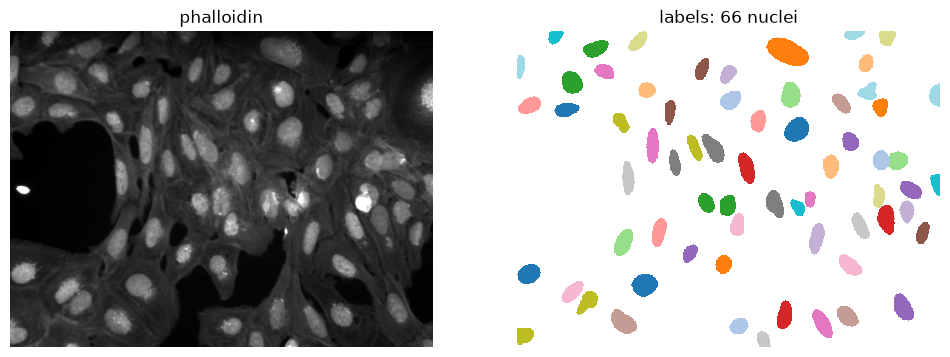

In [3]:
image = imread(DATA / 'images' / '1895787.tif')
labels = imread(DATA / 'labels' / '1895787.tif')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image, cmap='gray', vmin=np.percentile(image, 1), vmax=np.percentile(image, 99.8))
axes[0].set_title('phalloidin')
axes[1].imshow(np.ma.masked_equal(labels, 0), cmap='tab20', interpolation='nearest')
axes[1].set_title(f'labels: {labels.max()} nuclei')
for ax in axes:
    ax.axis('off')

Nobody checked all 100 label images that were automatically created. Let's count the nuclei in each of the image before we train on them.

In [ ]:
#We open the label images and count the number nuclei by the maximum value.
counts = pd.Series({f.name: imread(f).max() for f in label_files})

print(counts.describe().round(1))
print()
print('empty:', list(counts[counts == 0].index))

count    100.0
mean     107.0
std       38.4
min        0.0
25%       85.8
50%      111.0
75%      135.5
max      173.0
dtype: float64

empty: ['1897201.tif', '1898947.tif']


Two images have no nuclei. They teach the network nothing and they break the scores later
(you cannot ask how many of the nuclei we found when there are none), so leave them out of
the dataset you build below.

### Correct a label image in napari

The labels come from StarDist, so the model can at best learn StarDist's mistakes too. Open
one image in napari and fix its labels, as you did this morning. Then save it, before you
build the dataset in section 2.

If `import napari` fails, run `%pip install "napari[all]"` once in a new cell and restart the
kernel.

In [ ]:
import napari

image_id = '1895787'   # pick one, for example one with few nuclei in the counts above

viewer = napari.Viewer()
viewer.add_image(imread(DATA / 'images' / f'{image_id}.tif'), name='phalloidin')
viewer.add_labels(imread(DATA / 'labels' / f'{image_id}.tif'), name='labels')

In [ ]:
from skimage.io import imsave

imsave(DATA / 'labels' / f'{image_id}.tif', viewer.layers['labels'].data, check_contrast=False)

## 2. Splitting the data

Three piles:

- **training** — what the network learns from
- **validation** — checked every epoch, to see whether it is still improving or has started
  memorising the training images
- **test** — touched once, at the end. It is the only honest number you get, and the moment
  you use it to pick a setting it stops being one.

Images that are nearly the same must not end up in different piles: frames of a time lapse,
slices through one organoid, fields from one patient. Otherwise the test score tells you how
well the model remembers, not how well it works. `metadata.csv` tells you where each image
comes from.

In [ ]:
metadata = pd.read_csv(DATA / 'metadata.csv')
print(metadata.head())
print()
print(metadata['plate'].nunique(), 'plate(s),', metadata['well'].nunique(), 'wells,',
      len(metadata), 'images')
print(metadata['compound'].value_counts().head())

Can you split these images at random? What would you do if there were four fields per well?

### Exercise: build the dataset

Make this folder structure next to this notebook, from the files in `training_data/`:

```
dataset/
├── train/
│   ├── images/   # phalloidin
│   └── labels/   # nuclei
├── val/
│   ├── images/
│   └── labels/
└── test/
    ├── images/
    └── labels/
```

- Put about 20% of the images in `val/`, 20% in `test/`, the rest in `train/`.
- An image and its label keep the same file name and go to the same split.
- Leave out the images without nuclei.

Do it by hand in the file browser, or write a short script (`pathlib` and `shutil.copy` are
enough). Then run the cell below to check your result.

In [ ]:
DATASET = Path('dataset')

for folder in sorted(DATASET.glob('*/*')):
    print(folder, len(list(folder.glob('*.tif'))), 'files')

test_ids = sorted(f.stem for f in (DATASET / 'test' / 'images').glob('*.tif'))

## 3. The settings

BiaPy reads a YAML file. We take the template BiaPy publishes for 2D instance segmentation,
change a few settings from Python, and write it back out.

In [7]:
patch_size = 256     # the network trains on crops of this size, not whole images
epochs = 20          # one epoch is one pass over the training images
batch_size = 8       # crops through the network at once

# Start with the simplest thing we can ask of the network: for every pixel, is this a
# nucleus or not. Section 7 is about what else you could ask it.
data_channels = ['F']
job_name = 'run1_foreground'     # each run gets its own name, so nothing is overwritten
run_id = 1

output_path = 'training_output'

In [8]:
from urllib.request import urlretrieve

template = Path('2d_instance_segmentation.yaml')
if not template.exists():
    urlretrieve(
        'https://raw.githubusercontent.com/BiaPyX/BiaPy/v3.7.1/templates/'
        'instance_segmentation/2d_instance_segmentation.yaml',
        template,
    )

print(template.read_text())

# BiaPy version: 3.7.1

SYSTEM:
    NUM_CPUS: -1

PROBLEM:
    TYPE: INSTANCE_SEG
    NDIM: 2D
    INSTANCE_SEG:
        DATA_CHANNELS: BC
  
DATA: 
    PATCH_SIZE: (256, 256, 1)  
    TRAIN:                                                                                                              
        PATH: /path/to/data
        GT_PATH: /path/to/data
        IN_MEMORY: True
    VAL:
        SPLIT_TRAIN: 0.1
    TEST:                                                                                                               
        PATH: /path/to/data
        GT_PATH: /path/to/data
        IN_MEMORY: True
        LOAD_GT: True
        PADDING: (32,32)

AUGMENTOR:
    ENABLE: True
    RANDOM_ROT: True
    VFLIP: True
    HFLIP: True

MODEL:
    ARCHITECTURE: unet
    LOAD_CHECKPOINT: False

TRAIN:
    ENABLE: True
    OPTIMIZER: ADAMW
    LR: 1.E-4
    BATCH_SIZE: 8
    EPOCHS: 100
    PATIENCE: 20

# Loss function
LOSS:
    CLASS_REBALANCE: True # give the same weight to all 

Read that file into a dictionary, change what we need, save it under a new name. The
template stays untouched so you can always start over.

In [9]:
config = yaml.safe_load(template.read_text())

# what the network has to predict
config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'] = data_channels

# where the data is
config['DATA']['TRAIN']['PATH'] = 'dataset/train/images'
config['DATA']['TRAIN']['GT_PATH'] = 'dataset/train/labels'
config['DATA']['TEST']['PATH'] = 'dataset/test/images'
config['DATA']['TEST']['GT_PATH'] = 'dataset/test/labels'

# validation from its own folder, not taken out of the training images
config['DATA']['VAL']['FROM_TRAIN'] = False
config['DATA']['VAL']['PATH'] = 'dataset/val/images'
config['DATA']['VAL']['GT_PATH'] = 'dataset/val/labels'

# PATCH_SIZE has to be a string, that is how BiaPy reads it
config['DATA']['PATCH_SIZE'] = f'({patch_size}, {patch_size}, 1)'
config['TRAIN']['EPOCHS'] = epochs
config['TRAIN']['BATCH_SIZE'] = batch_size

run_config = Path('2d_instance_segmentation_config.yaml')
run_config.write_text(yaml.safe_dump(config, sort_keys=False))

print(run_config.read_text())

SYSTEM:
  NUM_CPUS: -1
PROBLEM:
  TYPE: INSTANCE_SEG
  NDIM: 2D
  INSTANCE_SEG:
    DATA_CHANNELS:
    - F
DATA:
  PATCH_SIZE: (256, 256, 1)
  TRAIN:
    PATH: dataset/train/images
    GT_PATH: dataset/train/labels
    IN_MEMORY: true
  VAL:
    SPLIT_TRAIN: 0.2
    FROM_TRAIN: true
  TEST:
    PATH: dataset/test/images
    GT_PATH: dataset/test/labels
    IN_MEMORY: true
    LOAD_GT: true
    PADDING: (32,32)
AUGMENTOR:
  ENABLE: true
  RANDOM_ROT: true
  VFLIP: true
  HFLIP: true
MODEL:
  ARCHITECTURE: unet
  LOAD_CHECKPOINT: false
TRAIN:
  ENABLE: true
  OPTIMIZER: ADAMW
  LR: 0.0001
  BATCH_SIZE: 8
  EPOCHS: 20
  PATIENCE: 20
LOSS:
  CLASS_REBALANCE: true
TEST:
  ENABLE: true
  AUGMENTATION: false
  FULL_IMG: false



## 4. Train

The output is long, so we use `%%capture` keeps it out of the notebook. Run
`biapy_out.show()` in a new cell if you want to read it.

In [11]:
%%capture biapy_out
from biapy import BiaPy

biapy = BiaPy(config=str(run_config), result_dir=output_path, name=job_name,
              run_id=run_id, gpu='0')

biapy.run_job()

In [12]:
results = Path(output_path) / job_name / 'results' / f'{job_name}_{run_id}'

for item in sorted(results.iterdir()):
    print(item.name)

[13:52:18.931082] aug
[13:52:18.931168] charts
[13:52:18.931184] instance_associations
[13:52:18.931197] per_image
[13:52:18.931209] per_image_instances
[13:52:18.931222] tensorboard
[13:52:18.931235] test_F_instance_channels
[13:52:18.931247] test_results_metrics.csv
[13:52:18.931260] train_F_instance_channels


## 5. Check the training graphs

BiaPy automatically plots the graphs and saves them in `charts/`.

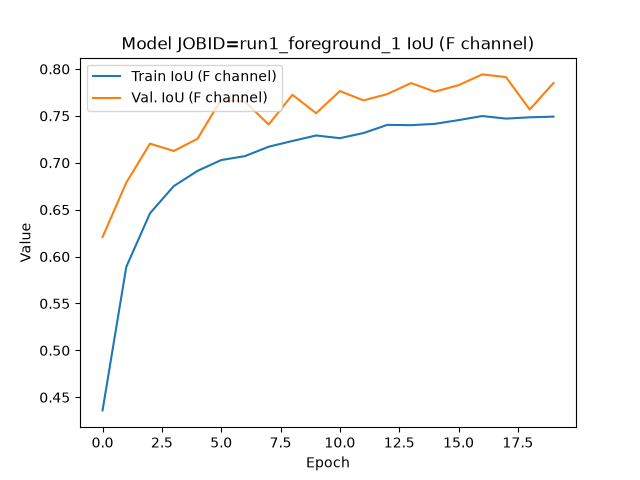

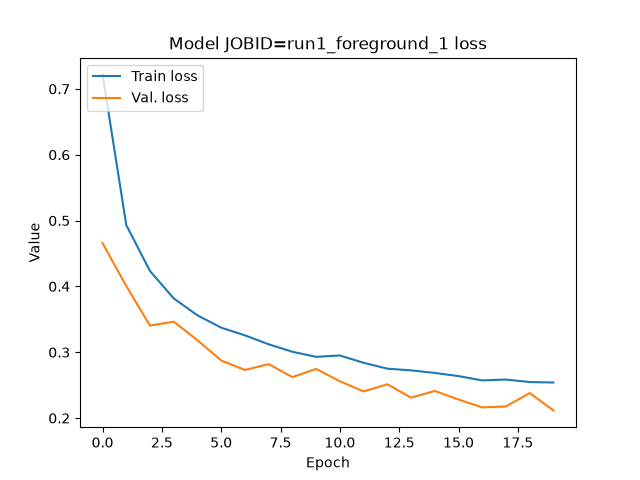

In [14]:
for chart in sorted((results / 'charts').glob('*.png')):
    display(Image(str(chart)))

The loss is how wrong the network is, so lower is better. Compare the training and
validation curves:

- both still going down at the last epoch: it can train longer
- both flat for a while: it has learned what it can
- training loss going down while validation loss goes up: it is memorising the training
  images. Stop earlier, augment more, or get more data.

Look at your own curves and decide which of these it is before changing anything.

The IoU plot shows the overlap between prediction and target, per channel.

## 6. What does it predict?

`TEST.ENABLE` is on in the template, so BiaPy already ran the model on the test images.

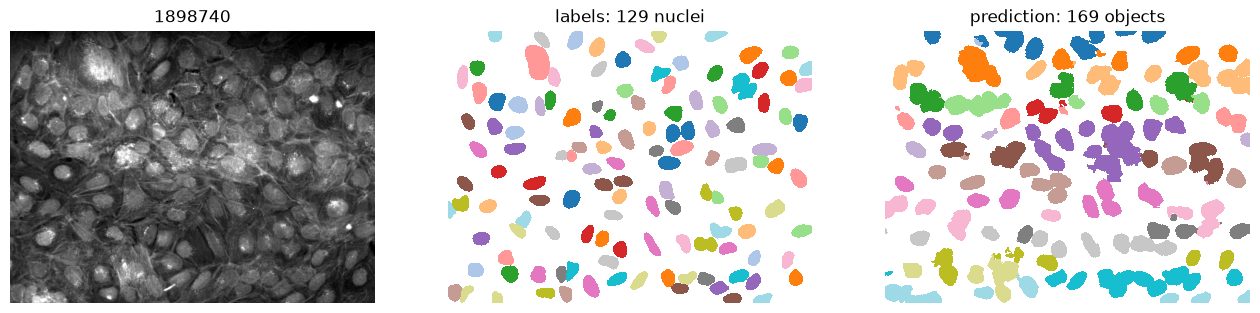

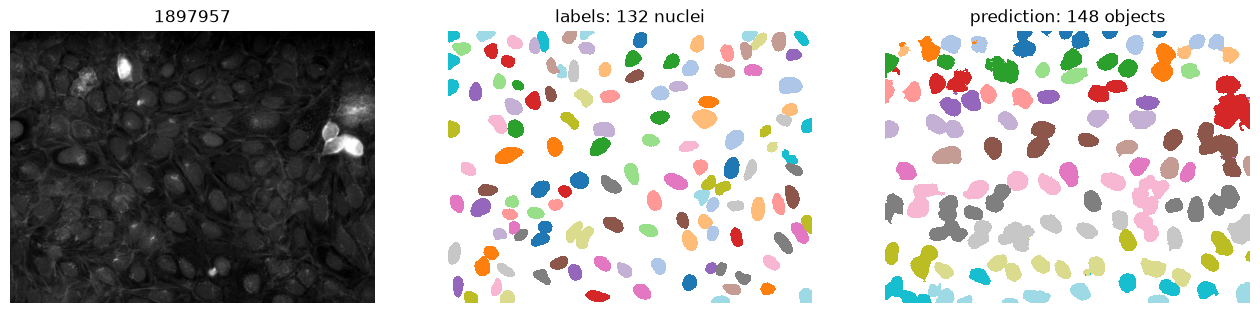

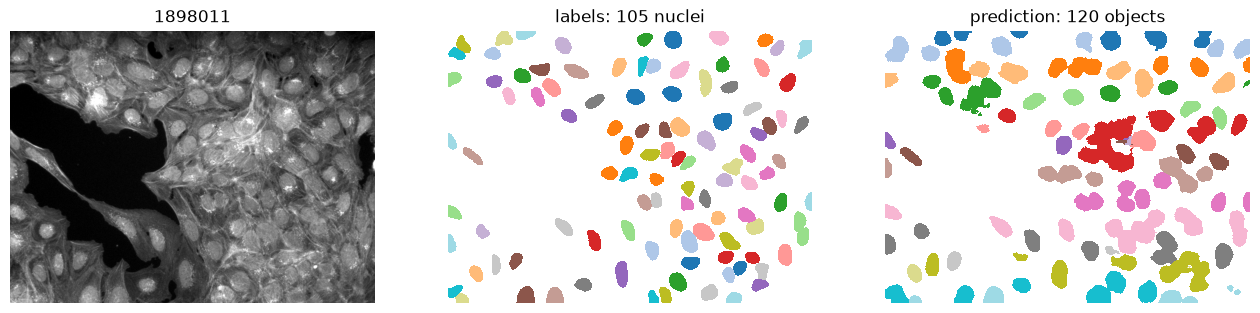

In [15]:
predictions = results / 'per_image_instances'

for image_id in test_ids[:3]:
    test_image = imread(DATASET / 'test' / 'images' / f'{image_id}.tif')
    test_labels = imread(DATASET / 'test' / 'labels' / f'{image_id}.tif')
    predicted = imread(predictions / f'{image_id}.tif')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(test_image, cmap='gray',
                   vmin=np.percentile(test_image, 1), vmax=np.percentile(test_image, 99.8))
    axes[0].set_title(image_id)
    axes[1].imshow(np.ma.masked_equal(test_labels, 0), cmap='tab20', interpolation='nearest')
    axes[1].set_title(f'labels: {test_labels.max()} nuclei')
    axes[2].imshow(np.ma.masked_equal(predicted, 0), cmap='tab20', interpolation='nearest')
    axes[2].set_title(f'prediction: {predicted.max()} objects')
    for ax in axes:
        ax.axis('off')
    plt.show()

Look at a dense patch: do you see two nuclei with one colour? Then they were segmented as one
object.

BiaPy also scored the test images. The scores are in `test_results_metrics.csv` in the results
folder.

The simplest score: how many objects. If your question is how many cells are in
a well, this may be all you need.

In [16]:
scores = pd.read_csv(results / 'test_results_metrics.csv')

n_objects = scores[['file', '0.5 TH n_true', '0.5 TH n_pred']].copy()
n_objects.columns = ['image', 'nuclei in the labels', 'objects found']

print(n_objects.head(10))
print()
print(n_objects.sum(numeric_only=True))

[13:52:50.204847]          image  nuclei in the labels  objects found
0  1895788.tif                   137            158
1  1895923.tif                   135            154
2  1895950.tif                   107            120
3  1896103.tif                     2            114
4  1896670.tif                    35             76
5  1896787.tif                   131            149
6  1896841.tif                   112            138
7  1897129.tif                    39             62
8  1897615.tif                    68             87
9  1897687.tif                    83            114
[13:52:50.208211] 
[13:52:50.208591] nuclei in the labels    1950
objects found           2450
dtype: int64


But a count says nothing about *where* the objects are. To decide whether a predicted object
*is* the same as a labelled one we can compare their overlapping pixels:
**intersection over union** (IoU), the pixels they share divided by the pixels they cover
together. 1.0 is identical, 0.5 is a reasonable overlap, 0.0 is no overlap at all.

Text(0.5, 0.98, 'IoU = 1451 / 2431 = 0.60')

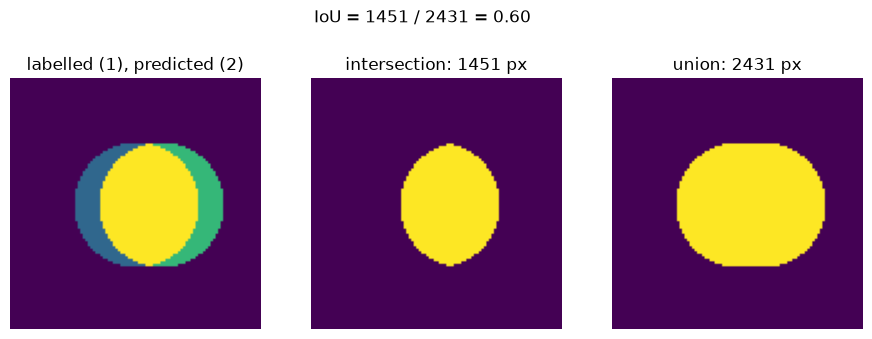

In [17]:
yy, xx = np.mgrid[:100, :100]
labelled = (yy - 50) ** 2 + (xx - 50) ** 2 < 25 ** 2
predicted = (yy - 50) ** 2 + (xx - 60) ** 2 < 25 ** 2

intersection = (labelled & predicted).sum()
union = (labelled | predicted).sum()

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, img, title in zip(
        axes,
        [labelled + 2 * predicted, labelled & predicted, labelled | predicted],
        ['labelled (1), predicted (2)', f'intersection: {intersection} px', f'union: {union} px']):
    ax.imshow(img, cmap='viridis')
    ax.set_title(title)
    ax.axis('off')

fig.suptitle(f'IoU = {intersection} / {union} = {intersection / union:.2f}')

## 7. How to separate merged nuclei?

A U-Net takes an image and returns an image. It cannot output "nucleus 17": the numbers in the
label image are arbitrary, and nothing tells the network that this blob should be 17 and the
next one 18. So BiaPy turns the labels into target images the network *can* learn, and rebuilds
the objects from the prediction afterwards. Those targets are the **data channels** we set in
section 3.

With `['F']` (foreground) the network only learns nucleus or not. Two touching nuclei become
one blob. With `['F', 'C']` it also learns the **contour** of each nucleus, and BiaPy uses that
to cut touching nuclei apart.

## 8. Run 2: add the contour to the target

In [22]:
config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'] = ['F', 'C']
job_name = 'run2_foreground_contour'

run_config.write_text(yaml.safe_dump(config, sort_keys=False))

print(config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'], '->', job_name)

[13:54:26.030152] ['F', 'C'] -> run2_foreground_contour


In [23]:
%%capture biapy_out

biapy = BiaPy(config=str(run_config), result_dir=output_path, name=job_name,
              run_id=run_id, gpu='0')

biapy.run_job()

In [24]:
run1 = Path(output_path) / 'run1_foreground' / 'results' / 'run1_foreground_1'
run2 = Path(output_path) / 'run2_foreground_contour' / 'results' / 'run2_foreground_contour_1'

scores1 = pd.read_csv(run1 / 'test_results_metrics.csv')
scores2 = pd.read_csv(run2 / 'test_results_metrics.csv')

interesting = ['0.5 TH n_true', '0.5 TH n_pred', '0.5 TH tp', '0.5 TH fp', '0.5 TH fn',
               '0.5 TH precision', '0.5 TH recall', '0.5 TH f1']

pd.DataFrame({
    'F': scores1[interesting].mean(),
    'F + C': scores2[interesting].mean(),
}).round(2)

,F,F + C
0.5 TH n_true,97.50,97.50
0.5 TH n_pred,122.50,168.00
0.5 TH tp,60.15,90.40
0.5 TH fp,62.35,77.60
0.5 TH fn,37.35,7.10
0.5 TH precision,0.50,0.56
0.5 TH recall,0.63,0.89
0.5 TH f1,0.56,0.68
0.5 TH mean_matched_score,0.70,0.69


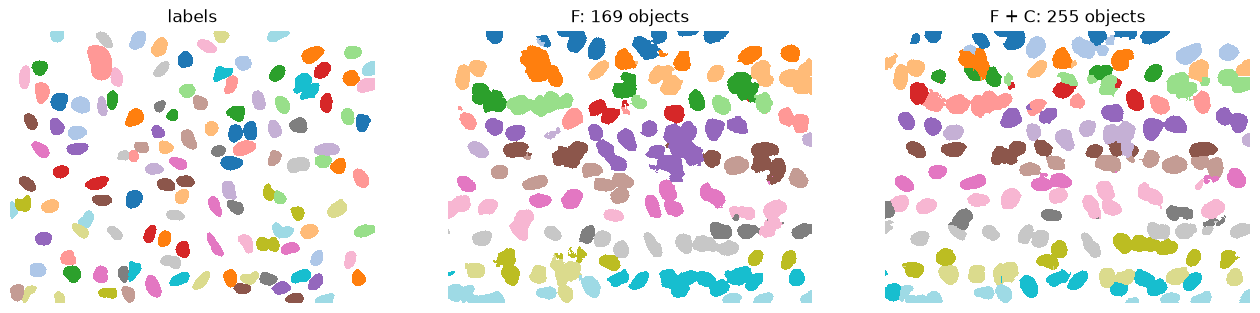

In [25]:
image_id = test_ids[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(np.ma.masked_equal(imread(DATASET / 'test' / 'labels' / f'{image_id}.tif'), 0),
               cmap='tab20', interpolation='nearest')
axes[0].set_title('labels')

for ax, run, name in zip(axes[1:], [run1, run2], ['F', 'F + C']):
    predicted = imread(run / 'per_image_instances' / f'{image_id}.tif')
    ax.imshow(np.ma.masked_equal(predicted, 0), cmap='tab20', interpolation='nearest')
    ax.set_title(f'{name}: {predicted.max()} objects')

for ax in axes:
    ax.axis('off')

Did the contour change the *number* of objects, their *outlines*, or both? Which column
tells you that? Did FN go down? That is where the merged nuclei were hiding.

Both runs got 20 epochs. Two channels is a harder job than one, so open run 2's charts and
see whether it had finished learning.

## 9. If you have time

Each of these is one line, then re-run the config cell, the training cell and the scoring
cells. Give every run its own `job_name`. They take as long as the runs above, so pick one
or two.

```python
config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'] = ['F', 'D']   # distance instead of contour
config['TRAIN']['EPOCHS'] = 60                                    # if the loss was still falling
config['AUGMENTOR']['ENABLE'] = False                             # it is on in the template
config['DATA']['PATCH_SIZE'] = '(128, 128, 1)'                    # smaller crops, less context
config['MODEL']['ARCHITECTURE'] = 'resunet'                       # a different network
```

The last one is what people try first and it is rarely where the gain is. Compare it with
what the contour channel did.

And the question worth asking before any of them: train on 20, 40 and all training
images (move images out of `dataset/train/`, then re-run the check cell) and plot F1 against
the number of training images. If that curve is still rising, annotating more images beats every setting
on this page.